In [27]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

from src.features.preprocessing_4classes import preprocessing
from src.models.model_utils import prepare_data

## En este notebook se realizan diferentes validaciones con el fin de evaluar qué tan bien está aprendiendo y generalizando el modelo.

In [28]:
df, X, y = preprocessing()

In [29]:
X_train, X_test, y_train, y_test = prepare_data(X, y)

In [30]:
modelo = joblib.load("../models/modelo_final_lightgbm_4clases.joblib")
classes = modelo.classes_

classes

array(['acoustic', 'mainstream', 'other', 'urban'], dtype=object)

In [32]:
y_score = modelo.predict_proba(X_test)

In [33]:
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = len(classes)

In [34]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

In [35]:
auc_df = pd.DataFrame({
    "Clase": classes,
    "AUC": [roc_auc[i] for i in range(n_classes)]
}).sort_values(by="AUC", ascending=False)

auc_df

,Clase,AUC
3,urban,0.921329
2,other,0.897014
0,acoustic,0.888256
1,mainstream,0.872148


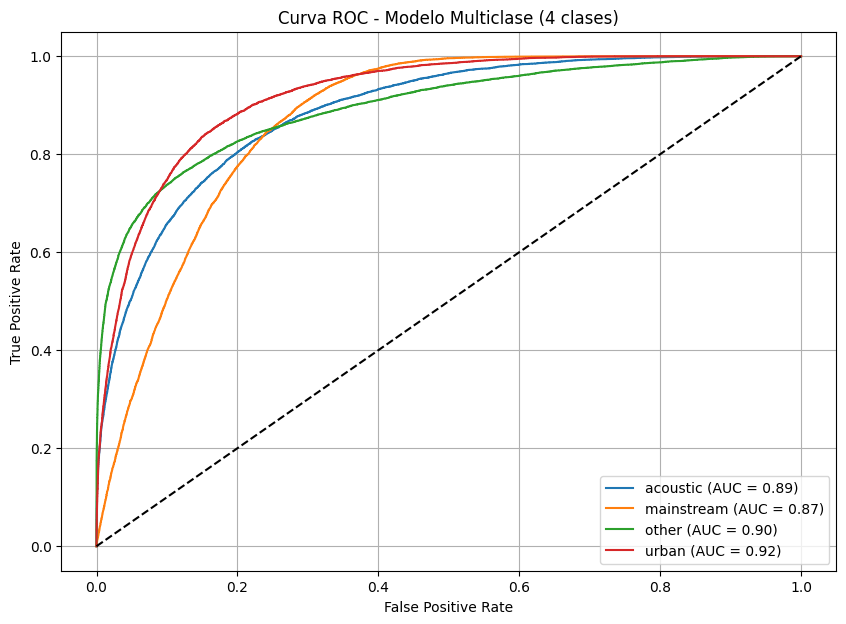

In [36]:
plt.figure(figsize=(10, 7))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"{classes[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Modelo Multiclase (4 clases)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Todas las curvas se encuentran muy por encima de la diagonal, lo que confirma que el modelo aprende patrones reales.

In [37]:
macro_auc = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
macro_auc

0.8946869623570313

El valor de AUC macro = 0.895 indica que, en promedio, el modelo tiene una muy buena capacidad para distinguir entre clases, significativamente por encima del comportamiento aleatorio (AUC = 0.5).

El modelo presenta un desempeño robusto y balanceado entre clases, con una alta capacidad de discriminación global. La diferencia entre clases es baja, lo que indica que no existe un sesgo fuerte hacia una categoría específica.